# **Lab 2 – Tidying, Cleaning, Imputation, and Outlier Detection**

## Machine Learning Programming

This assignment continues the work started in **`week5Lab.ipynb`**.  
Open this notebook and complete the activities **in this notebook**, preserving the section order and the overall structure.

The purpose of this lab is to practice the data-preprocessing work that normally takes place before machine learning: reshaping data, cleaning inconsistent values, handling missing data, detecting outliers, visualizing results, and explaining the decisions you make.

## **Assignment Overview**

### Purpose
By the end of this lab, you should be able to take several imperfect datasets and make them more suitable for analysis and later machine-learning work.

### Learning Outcomes
You will practice how to:

- inspect the shape, columns, data types, and quality of a dataset;
- distinguish **wide** and **long/tidy** data;
- reshape data with `pd.melt()` or `DataFrame.melt()`;
- clean strings using Pandas string methods;
- identify, quantify, drop, and impute missing values;
- compare mean, median, mode, and `SimpleImputer` approaches;
- identify outliers visually with box plots and scatter plots;
- identify outliers statistically using **Z-Scores** and **IQR**;
- justify preprocessing decisions using evidence from the data;
- document a reproducible Python data-processing workflow.

### Estimated Completion Time
Approximately **2.5–3.5 hours**, depending on your Python experience.

## **Submission and Project Structure**

Keep the project organized so another person can reproduce your work.

Recommended structure:

```text
project/
├── week5Lab.ipynb
├── README.md
├── requirements.txt
├── .gitignore
└── data/
    ├── pew-raw.csv
    ├── billboard.csv
    ├── cars.csv
    └── diabetes.csv
```

A clearly named equivalent data folder such as `CSVs/` or `datasets/` is also acceptable if all notebook paths are updated consistently.

### Required submission artifacts

- `week5Lab.ipynb` containing **all four completed sections**
- `README.md` with at least 1–2 meaningful sentences describing the lab and how to run it
- `requirements.txt` containing the packages required to reproduce the environment
- `.gitignore`
- all required data files inside a clearly named data folder

**Important:** Use relative paths such as `./data/cars.csv`. Do not use absolute paths from your own computer.

**Environment practice:** Use `requirements.txt` to define the environment. Do not add `!pip install ...` cells to the notebook when a requirements file is provided.

## **Before You Begin**

Use the following libraries where appropriate:

- `pandas`
- `numpy`
- `matplotlib`
- `seaborn`
- `scikit-learn`

Run the import cell below before beginning the exercises.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer

# Optional display settings
pd.set_option("display.max_columns", None)

## **General Expectations**

For every section:

1. Write the required Python code.
2. Display enough output to demonstrate that the code works.
3. Add short Markdown explanations in your own words.
4. Label plots clearly with a title and axis labels.
5. Explain what the output means instead of only producing it.
6. Preserve the required section headings so the notebook is easy to follow.
7. Before submitting, restart the kernel and use **Run All** to confirm the notebook executes from beginning to end.

# **Section 1 – PEW Research Dataset**

## **Learning Topic: Data Tidying and Reshaping**

A dataset is commonly described as **tidy** when:

1. each variable forms a column;
2. each observation forms a row; and
3. each type of observational unit forms a table.

The PEW dataset represents counts for religions across income ranges. In its original form, income values appear as column headings. You will reshape the dataset from **wide** format to **long/tidy** format using `melt()`.

### Required concepts
- dataset inspection
- wide versus long data
- identifier variables
- measured variables
- `pd.melt()` or `DataFrame.melt()`
- visualization after reshaping

## **Getting the PEW Dataset from the Internet**

For this lab, use the small **PEW religion-and-income dataset** commonly used to demonstrate tidy-data principles. This is the dataset whose first column is `religion` and whose remaining columns are income ranges such as `<$10k`, `$10-20k`, and `$20-30k`.

### Recommended method — download in your browser

1. Open the dataset in a browser:
   `https://raw.githubusercontent.com/nickhould/tidy-data-python/master/data/pew-raw.csv`
2. Save the file as **`pew-raw.csv`**.
3. Create a folder named **`data`** in the same project folder as this notebook if it does not already exist.
4. Move `pew-raw.csv` into the `data` folder.
5. Confirm that your project contains:

```text
project/
├── week5Lab.ipynb
└── data/
    └── pew-raw.csv
```

6. Load the local copy with:

```python
df_pew = pd.read_csv("./data/pew-raw.csv")
```

### Optional Python-assisted download

The following is an example only. You may use it once to obtain the dataset, but your submitted analysis should subsequently read the **local copy** from `./data/`.

```python
from pathlib import Path
import pandas as pd

Path("data").mkdir(exist_ok=True)

url = "https://raw.githubusercontent.com/nickhould/tidy-data-python/master/data/pew-raw.csv"
df_pew = pd.read_csv(url)
df_pew.to_csv("./data/pew-raw.csv", index=False)
```

### Verify before continuing

After loading the file, check that the dataframe contains a `religion` column and multiple income-range columns. If it does not, stop and verify that you downloaded the correct dataset.

> **Good reproducibility practice:** Do not depend on the Internet every time the notebook runs. Download the dataset once, store it in the project's `data/` folder, commit the permitted data file to your repository, and use a relative path in the notebook.

### **Task 1.1 – Load and Inspect the Dataset**

1. Load the PEW dataset from your data folder.
2. Display its shape.
3. Display its column names.
4. Display several rows using `head()`, `loc`, `iloc`, or `tail()`.
5. Identify the column that should remain the identifier variable.

In [2]:
# TODO: Load the PEW dataset using a RELATIVE path.
# Example:
# df_pew = pd.read_csv("./data/pew-raw.csv")

pew = pd.read_csv("../data/pew-raw.csv")

# TODO: Display shape, columns, and several rows.

print("Shape:", pew.shape)
display(pew.head())

Shape: (10, 7)


,religion,<$10k,$10-20k,$20-30k,$30-40k,$40-50k,$50-75k
0,Agnostic,27,34,60,81,76,137
1,Atheist,12,27,37,52,35,70
2,Buddhist,27,21,30,34,33,58
3,Catholic,418,617,732,670,638,1116
4,Dont know/refused,15,14,15,11,10,35


### **Task 1.2 – Explain the Problem**

In a Markdown cell below, answer:

- What is not tidy about the original PEW dataset?
- Which values are stored in column names?
- Which column should be treated as the identifier (`id_vars`)?

> **TODO – Your explanation:**  

- What is not tidy about the original PEW dataset?

According to the problem of Tidy Data, the data must be grouped so that it is easier to manage; on this data, a structure that is easier to manage would bring together an entire column for the 'income' range and another column for the number of people, meeting the norm to improve the organization, filtering and analysis of the data set.

- Which values are stored in column names?

Income ranges are stored in column names like `<$10k` , `$10-20k` , `$20-30k` and other income categories.

- Which column should be treated as the identifier (`id_vars`)?

The 'religion' column should be used as an identifier because it tells us that the name of the religion belongs to each information


### **Task 1.3 – Reshape with `melt()`**

Use either of these valid Pandas forms:

```python
pd.melt(...)
```

or

```python
df.melt(...)
```

Your result should have meaningful names for the new variable and value columns, such as `income` and `count`.

In [3]:
# TODO: Reshape the PEW dataframe from wide to long format with melt().
pew_long = pd.melt(
    pew,
    id_vars=["religion"],
    var_name="income",
    value_name="count"
)

# TODO: Display the first rows of the reshaped dataframe.
display(pew_long.head())

# TODO: Compare the original and reshaped shapes.
print("Original shape:", pew.shape)
print("Reshaped shape:", pew_long.shape)


,religion,income,count
0,Agnostic,<$10k,27
1,Atheist,<$10k,12
2,Buddhist,<$10k,27
3,Catholic,<$10k,418
4,Dont know/refused,<$10k,15


Original shape: (10, 7)
Reshaped shape: (60, 3)


### **Task 1.4 – Visualize the Tidy Data**

Create at least **one meaningful visualization** from the reshaped dataset.

Possible questions include:

- How do counts differ across income groups?
- How do selected religions compare across income groups?

Your plot must include a title and axis labels.

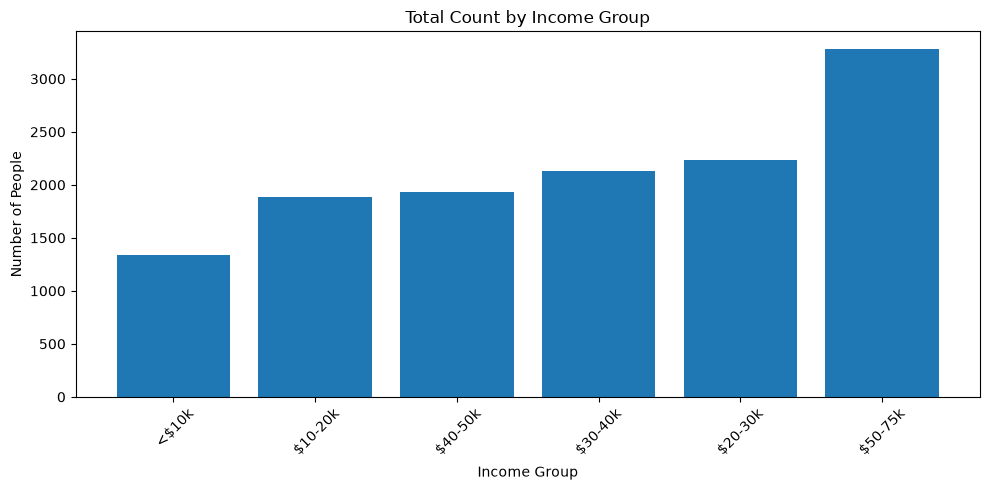

In [4]:
# TODO: Create a visualization using the reshaped PEW data.
# Group the data by income range and calculate the total count
income_counts = (
    pew_long
    .groupby("income")["count"]
    .sum()
    .reset_index()
)

# Sort from lowest to highest count
income_counts = income_counts.sort_values(
    by="count",
    ascending=True
)

# Create the visualization
plt.figure(figsize=(10, 5))

plt.bar(
    income_counts["income"],
    income_counts["count"]
)

# Add title and axis labels
plt.title("Total Count by Income Group")
plt.xlabel("Income Group")
plt.ylabel("Number of People")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()




This graph compares the total number of people across income groups.

This graphic helps us visualize more easily all the income categories and number of people that exist in each income regardless of religion.

According to the graphics, we can observe conclusions that income '50-75K' has the largest number of people surveyed within this range. 

### **Task 1.5 – PEW Reflection**

Answer **all** questions briefly in your own words:

1. What was the main structural problem with the original dataset?
2. What does `id_vars` mean in `melt()`?
3. What information moved from columns into rows?
4. How did the number of rows change after reshaping, and why?
5. Why is the long format easier to analyze or visualize?
6. What did your visualization reveal?

> **TODO – PEW observations and reflection:**  

- What was the main structural problem with the original dataset?

The main problem was that income groups were stored as separate columns, was unified to have a data easier to manage and read

- What does `id_vars` mean in `melt()`?

`id_vars` tells the method `melt()` which column stay the same while the other columns are transformed. In this case, `religion` was used as the ID.

- What information moved from columns into rows?

The income ranges, such as `<$10k`, `$10-20k`, and the other categories, were moved from column names into rows under the `income` column.

- How did the number of rows change after reshaping, and why?

The number of rows increased because each religion now has one row for each income group instead of having all the income groups in separate columns.

- Why is the long format easier to analyze or visualize?

The long format is easier because all revenue values are stored within a single column, being a single column translates to a single variable which can be done methods instead of several joins to more than one variable

- What did your visualization reveal?

The visualization showed income values in ascending order, leading us to conclude that as income increases the number of people also increased in each category.


# **Section 2 – Billboard Dataset**

## **Learning Topic: Advanced Data Tidying**

The Billboard dataset stores weekly song rankings across many week columns. You will reshape those columns into rows, clean the resulting week labels, convert ranking values to appropriate data types, handle missing values, and analyze ranking trends.

### Required concepts
- `pd.melt()` or `DataFrame.melt()`
- Pandas string methods such as:
  - `.str.replace()`
  - `.str.strip()`
  - `.str.extract()`
  - `.str.upper()`
  - `.str.lower()`
- numeric conversion
- missing-value handling
- dates / timedeltas where appropriate

## **Getting the Billboard Dataset from the Internet**

Use the **Billboard weekly ranking dataset** associated with the classic tidy-data example. The correct file contains song information plus many weekly ranking columns such as `1st week`, `2nd week`, etc. (column names can vary slightly between copies).

### Recommended method — download in your browser

1. Open this public copy of `billboard.csv`:
   `https://gist.githubusercontent.com/AdrianLl/bd94c12f2b3c3a899c4ca13d0a548966/raw/billboard.csv`
2. Save the file as **`billboard.csv`**.
3. Place it inside your project's **`data`** folder.
4. Your project should now include:

```text
project/
├── week5Lab.ipynb
└── data/
    ├── pew-raw.csv
    └── billboard.csv
```

5. Load the local file. If ordinary UTF-8 decoding fails, try `encoding="unicode_escape"`:

```python
billboard = pd.read_csv("./data/billboard.csv", encoding="unicode_escape")
```

### Optional Python-assisted download

```python
from pathlib import Path
import pandas as pd

Path("data").mkdir(exist_ok=True)

url = "https://gist.githubusercontent.com/AdrianLl/bd94c12f2b3c3a899c4ca13d0a548966/raw/billboard.csv"
billboard = pd.read_csv(url, encoding="unicode_escape")
billboard.to_csv("./data/billboard.csv", index=False)
```

### Verify before continuing

Inspect `billboard.columns`. You should see identifying information for songs/artists and a sequence of weekly ranking columns. Those repeated week columns are the columns you will later reshape with `melt()`.

> **Important:** Different online copies sometimes use slightly different column names. Do not blindly copy column names from an example. Inspect **your downloaded file** first and adapt your code accordingly.

### **Task 2.1 – Load and Inspect Billboard Data**

1. Load the Billboard dataset.
2. If normal UTF-8 decoding fails, try `encoding="unicode_escape"`.
3. Display its shape, columns, and first rows.
4. Identify the columns that represent weekly rankings.

In [5]:
# TODO: Load the Billboard dataset from your data folder.
billboard = pd.read_csv(
    "../data/billboard.csv",
    encoding="unicode_escape"
)
# Remove spaces in column names.
billboard.columns = billboard.columns.str.strip()

# Convert date columns to datetime early so they are ready for Task 2.6.
if "date entered" in billboard.columns:
    billboard["date entered"] = pd.to_datetime(
        billboard["date entered"], errors="coerce"
    )
if "date peaked" in billboard.columns:
    billboard["date peaked"] = pd.to_datetime(
        billboard["date peaked"], errors="coerce"
    )

print("\nData types:")
print(billboard.dtypes)

# TODO: Inspect shape, columns, data types, and first rows.
# Display the dataset shape
print("Shape:", billboard.shape)

# Display all column names
print("\nColumns:")
print(billboard.columns.tolist())

# Display the first rows
display(billboard.head())


Data types:
artist                     str
track                      str
duration                 int64
genre                      str
date entered    datetime64[us]
                     ...      
61st week              float64
62nd week              float64
63rd week              float64
64th week              float64
65th week              float64
Length: 77, dtype: object
Shape: (317, 77)

Columns:
['artist', 'track', 'duration', 'genre', 'date entered', 'date peaked', 'weeks to peak', 'weeks on chart', 'worst position', 'best position', 'enter rank', 'exit rank', '1st week', '2nd week', '3rd week', '4th week', '5th week', '6th week', '7th week', '8th week', '9th week', '10th week', '11th week', '12th week', '13th week', '14th week', '15th week', '16th week', '17th week', '18th week', '19th week', '20th week', '21st week', '22nd week', '23rd week', '24th week', '25th week', '26th week', '27th week', '28th week', '29th week', '30th week', '31st week', '32nd week', '33rd week', '34t

,artist,track,duration,genre,date entered,date peaked,weeks to peak,weeks on chart,worst position,best position,enter rank,exit rank,1st week,2nd week,3rd week,4th week,5th week,6th week,7th week,8th week,9th week,10th week,11th week,12th week,13th week,14th week,15th week,16th week,17th week,18th week,19th week,20th week,21st week,22nd week,23rd week,24th week,25th week,26th week,27th week,28th week,29th week,30th week,31st week,32nd week,33rd week,34th week,35th week,36th week,37th week,38th week,39th week,40th week,41st week,42nd week,43rd week,44th week,45th week,46th week,47th week,48th week,49th week,50th week,51st week,52nd week,53rd week,54th week,55th week,56th week,57th week,58th week,59th week,60th week,61st week,62nd week,63rd week,64th week,65th week
0,Destiny's Child,Independent Women Part I,218,Rock,2000-09-23,2000-11-18,8,28,78,1,78,31,78,63.0,49.0,33.0,23.0,15.0,7.0,5.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,3.0,7.0,10.0,12.0,15.0,22.0,29.0,31.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Santana,"Maria, Maria",258,Rock,2000-02-12,2000-04-08,8,26,48,1,15,47,15,8.0,6.0,5.0,2.0,3.0,2.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,8.0,15.0,19.0,21.0,26.0,36.0,48.0,47.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Savage Garden,I Knew I Loved You,247,Rock,1999-10-23,2000-01-29,14,33,71,1,71,47,71,48.0,43.0,31.0,20.0,13.0,7.0,6.0,4.0,4.0,4.0,6.0,4.0,2.0,1.0,1.0,1.0,2.0,1.0,2.0,4.0,8.0,8.0,12.0,14.0,17.0,21.0,24.0,30.0,34.0,37.0,46.0,47.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Madonna,Music,225,Rock,2000-08-12,2000-09-16,5,24,44,1,41,44,41,23.0,18.0,14.0,2.0,1.0,1.0,1.0,1.0,2.0,2.0,2.0,2.0,2.0,4.0,8.0,11.0,16.0,20.0,25.0,27.0,27.0,29.0,44.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"Aguilera, Christina",Come On Over Baby (All I Want Is You),218,Rock,2000-08-05,2000-10-14,10,21,57,1,57,44,57,47.0,45.0,29.0,23.0,18.0,11.0,9.0,9.0,11.0,1.0,1.0,1.0,1.0,4.0,8.0,12.0,22.0,23.0,43.0,44.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Clean column names
billboard.columns = billboard.columns.str.strip()

# Identify only weekly ranking columns
weekly_columns = [
    column for column in billboard.columns
    if "week" in column.lower()
    and column.lower() not in ["weeks to peak", "weeks on chart"]
]

print("Number of weekly ranking columns:", len(weekly_columns))
print(weekly_columns)

print("\nNumber of weekly ranking columns:", len(weekly_columns))

Number of weekly ranking columns: 65
['1st week', '2nd week', '3rd week', '4th week', '5th week', '6th week', '7th week', '8th week', '9th week', '10th week', '11th week', '12th week', '13th week', '14th week', '15th week', '16th week', '17th week', '18th week', '19th week', '20th week', '21st week', '22nd week', '23rd week', '24th week', '25th week', '26th week', '27th week', '28th week', '29th week', '30th week', '31st week', '32nd week', '33rd week', '34th week', '35th week', '36th week', '37th week', '38th week', '39th week', '40th week', '41st week', '42nd week', '43rd week', '44th week', '45th week', '46th week', '47th week', '48th week', '49th week', '50th week', '51st week', '52nd week', '53rd week', '54th week', '55th week', '56th week', '57th week', '58th week', '59th week', '60th week', '61st week', '62nd week', '63rd week', '64th week', '65th week']

Number of weekly ranking columns: 65


# Identify the weekly ranking columns
weekly_columns = [
    column for column in billboard.columns
    if column.startswith("x") and ".week" in column
]

print("Weekly ranking columns:")
print(weekly_columns)

print("\nNumber of weekly columns:", len(weekly_columns))

### **Task 2.2 – Diagnose the Tidiness Problem**

Explain why having columns such as week 1, week 2, week 3, etc. makes the dataset difficult to analyze.

Identify:

- identifier columns;
- weekly measured columns; and
- the variables you want after reshaping.

> **TODO – Your explanation:**  

The main problem like the previous data is that weekly classifications are in many separate columns (week 1, week 2, week 3, etc.) this can be organized so that there is only one variable left and then be able to handle it in code more easily

- Identifier columns:

The general information that describes each song could be summarized in columns such as `artist`, `track`, `duration`, `genre` and other date columns 

- Weekly measured columns:

The columns such as `1st_week`, `2nd_week`, `3rd_week`, and the other weekly ranking columns store the ranking position for each week.

- Variables after reshaping:

After the reshaping, there should be a column called `week` to store the number of weeks that each song was placed and another column called `rank` to save the position that that song had on Billboard.


### **Task 2.3 – Reshape with `melt()`**

Reshape the weekly ranking columns into a long structure.

Your result should contain:

- the song/artist identifiers;
- a `Week`-type column; and
- a `Rank`-type column.

In [7]:
# TODO: Identify id_vars and weekly value_vars.
# TODO: Reshape with pd.melt(...) OR billboard.melt(...).
billboard_long = pd.melt(
    billboard,
    id_vars=["artist", "track", "date entered"],
    value_vars=weekly_columns,
    var_name="Week",
    value_name="Rank"
)

# TODO: Display the reshaped dataframe.
display(billboard_long)

# Compare shapes
print("Original shape:", billboard.shape)
print("Reshaped shape:", billboard_long.shape)

,artist,track,date entered,Week,Rank
0,Destiny's Child,Independent Women Part I,2000-09-23,1st week,78.0
1,Santana,"Maria, Maria",2000-02-12,1st week,15.0
2,Savage Garden,I Knew I Loved You,1999-10-23,1st week,71.0
3,Madonna,Music,2000-08-12,1st week,41.0
4,"Aguilera, Christina",Come On Over Baby (All I Want Is You),2000-08-05,1st week,57.0
...,...,...,...,...,...
20600,Ghostface Killah,Cherchez LaGhost,2000-08-05,65th week,NaN
20601,"Smith, Will",Freakin' It,2000-02-12,65th week,NaN
20602,Zombie Nation,Kernkraft 400,2000-09-02,65th week,NaN
20603,"Eastsidaz, The",Got Beef,2000-07-01,65th week,NaN


Original shape: (317, 77)
Reshaped shape: (20605, 5)


### **Task 2.4 – Clean the Week Labels with String Operations**

Use Pandas string manipulation to clean the week labels.

Demonstrate **at least three** relevant string operations. Examples include:

```python
.str.replace(...)
.str.strip()
.str.extract(...)
.str.lower()
.str.upper()
```

Convert the extracted week number to a numeric type after cleaning.

In [8]:
# TODO: Clean the Week column using Pandas .str methods.
 # Clean column names
billboard_long["Week"] = billboard_long["Week"].str.strip()

# Convert text to lowercase
billboard_long["Week"] = billboard_long["Week"].str.lower()

# Replace underscores with spaces so different copies use one format.
billboard_long["Week"] = billboard_long["Week"].str.replace(
    "_", " ", regex=False
)

# TODO: Extract the week number.
# Identify only the weekly ranking columns
billboard_long["Week"] = billboard_long["Week"].str.replace(
    "week",
    "",
    regex=False
)

# TODO: Convert the week number to numeric.
# Extract only the numeric part
billboard_long["Week"] = billboard_long["Week"].str.extract(r"(\d+)")[0]

# Convert the week number to integer
billboard_long["Week"] = billboard_long["Week"].astype(int)

# TODO: Display the cleaned Week values.
# Display the cleaned result
display(billboard_long.head())
billboard_long.info()

,artist,track,date entered,Week,Rank
0,Destiny's Child,Independent Women Part I,2000-09-23,1,78.0
1,Santana,"Maria, Maria",2000-02-12,1,15.0
2,Savage Garden,I Knew I Loved You,1999-10-23,1,71.0
3,Madonna,Music,2000-08-12,1,41.0
4,"Aguilera, Christina",Come On Over Baby (All I Want Is You),2000-08-05,1,57.0


<class 'pandas.DataFrame'>
RangeIndex: 20605 entries, 0 to 20604
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   artist        20605 non-null  str           
 1   track         20605 non-null  str           
 2   date entered  20605 non-null  datetime64[us]
 3   Week          20605 non-null  int64         
 4   Rank          5307 non-null   float64       
dtypes: datetime64[us](1), float64(1), int64(1), str(2)
memory usage: 805.0 KB


### **Task 2.5 – Clean Ranking Values and Missing Data**

1. Convert ranking values to numeric using an appropriate method such as `pd.to_numeric()`.
2. Identify missing rankings.
3. Decide whether missing ranking rows should be dropped, retained, or treated another way.
4. Explain your decision.

In [9]:
# TODO: Convert ranking values to numeric.
# Any invalid value will become NaN
billboard_long["Rank"] = pd.to_numeric(
    billboard_long["Rank"],
    errors="coerce"
)

# TODO: Count missing values.
missing_rankings = billboard_long["Rank"].isna().sum()
print("Missing ranking values:", missing_rankings)

display(
    billboard_long[
        billboard_long["Rank"].isna()
    ].head()
)

# TODO: Apply your chosen missing-value treatment.
# Remove rows where Rank is missing
billboard_clean = billboard_long.dropna(
    subset=["Week", "Rank"]
).copy()

# Convert Rank to integer after removing missing values
billboard_clean["Week"] = billboard_clean["Week"].astype(int)
billboard_clean["Rank"] = billboard_clean["Rank"].astype(int)

# Check the result
print("Original long shape:", billboard_long.shape)
print("Clean shape:", billboard_clean.shape)

display(billboard_clean.head())


Missing ranking values: 15298


,artist,track,date entered,Week,Rank
588,"Estefan, Gloria",No Me Dejes De Querer,2000-06-10,2,NaN
618,Anastacia,I'm Outta Love,2000-04-01,2,NaN
628,Master P,Souljas,2000-11-18,2,NaN
629,Ghostface Killah,Cherchez LaGhost,2000-08-05,2,NaN
633,Fragma,Toca's Miracle,2000-10-28,2,NaN


Original long shape: (20605, 5)
Clean shape: (5307, 5)


,artist,track,date entered,Week,Rank
0,Destiny's Child,Independent Women Part I,2000-09-23,1,78
1,Santana,"Maria, Maria",2000-02-12,1,15
2,Savage Garden,I Knew I Loved You,1999-10-23,1,71
3,Madonna,Music,2000-08-12,1,41
4,"Aguilera, Christina",Come On Over Baby (All I Want Is You),2000-08-05,1,57


As we can see in the table and in the identification of 'missing values', some songs do not have a rank value, which makes us understand that not all the songs were classified in the Billboard ranking each week.

These records are deleted as they do not provide significant significance for information analysis


### **Task 2.6 – Optional Date Enhancement**

If the dataset contains a song's entry date, calculate the approximate chart date for each weekly observation using a `Timedelta`.

Document the equation you use and check for off-by-one-week errors.

In [10]:
# TODO (recommended): Calculate the date associated with each weekly ranking.
# Equation:
# ChartDate = date entered + (Week - 1) * 7 days
# Week 1 uses +0 days, which avoids an off-by-one-week error.

billboard_clean["ChartDate"] = (
    billboard_clean["date entered"]
    + pd.to_timedelta((billboard_clean["Week"] - 1) * 7, unit="D")
)

display(
    billboard_clean[
        ["artist", "track", "date entered", "Week", "Rank", "ChartDate"]
    ]
)



,artist,track,date entered,Week,Rank,ChartDate
0,Destiny's Child,Independent Women Part I,2000-09-23,1,78,2000-09-23
1,Santana,"Maria, Maria",2000-02-12,1,15,2000-02-12
2,Savage Garden,I Knew I Loved You,1999-10-23,1,71,1999-10-23
3,Madonna,Music,2000-08-12,1,41,2000-08-12
4,"Aguilera, Christina",Come On Over Baby (All I Want Is You),2000-08-05,1,57,2000-08-05
...,...,...,...,...,...,...
19663,Lonestar,Amazed,1999-06-05,63,45,2000-08-12
19700,Creed,Higher,1999-09-11,63,50,2000-11-18
19980,Lonestar,Amazed,1999-06-05,64,50,2000-08-19
20017,Creed,Higher,1999-09-11,64,50,2000-11-25


### **Task 2.7 – Billboard Visualization and Trend Analysis**

Create at least **one visualization** showing a meaningful Billboard trend.

Examples:

- ranking over time for a selected song;
- comparison of ranking trajectories for multiple songs;
- distribution of chart ranks by week.

Remember: on Billboard, a **smaller rank number is better**.

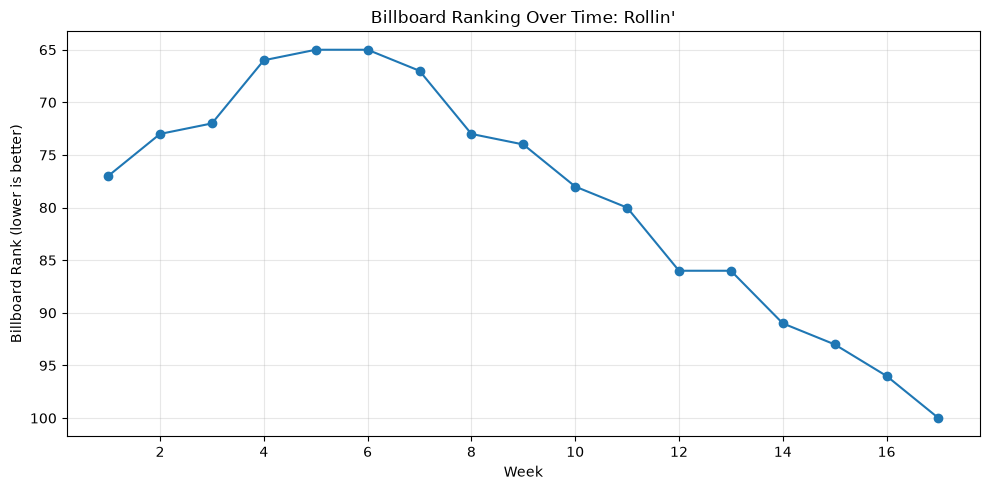

Selected artist: Limp Bizkit
Selected track: Rollin'
Best rank: 65
Weeks with a recorded rank: 17


In [11]:
# TODO: Create and label a meaningful Billboard visualization.

preferred_artist = "Limp Bizkit"
preferred_track = "Rollin'"

song_data = billboard_clean[
    (billboard_clean["artist"] == preferred_artist)
    & (billboard_clean["track"] == preferred_track)
].sort_values("Week")

# Fallback in case a different Billboard copy is used.
if song_data.empty:
    top_song = (
        billboard_clean.groupby(["artist", "track"])
        .size()
        .sort_values(ascending=False)
        .index[0]
    )
    song_data = billboard_clean[
        (billboard_clean["artist"] == top_song[0])
        & (billboard_clean["track"] == top_song[1])
    ].sort_values("Week")
    preferred_artist, preferred_track = top_song

plt.figure(figsize=(10, 5))
plt.plot(song_data["Week"], song_data["Rank"], marker="o")
plt.gca().invert_yaxis()  # Rank 1 is the best position.
plt.title(f"Billboard Ranking Over Time: {preferred_track}")
plt.xlabel("Week")
plt.ylabel("Billboard Rank (lower is better)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Selected artist:", preferred_artist)
print("Selected track:", preferred_track)
print("Best rank:", song_data["Rank"].min())
print("Weeks with a recorded rank:", len(song_data))

### **Task 2.8 – Billboard Reflection**

Answer all questions:

1. Why was `melt()` appropriate for the weekly ranking columns?
2. Which string operations did you use and what did each accomplish?
3. Why should the cleaned week number be numeric?
4. How did you handle missing ranking values, and why?
5. What trend did your visualization reveal?
6. What data-quality issue could lead to an incorrect ranking trend?
7. How is this Billboard transformation more complex than the PEW transformation?

> **TODO – Billboard observations and reflection:**  

- Why was `melt()` appropriate for the weekly ranking columns?

As mentioned before, weekly positions were stored too many columns. `melt()` so this method is perfect for grouping everything together so that each row is one song in a week.

- Which string operations did you use and what did each accomplish?

Used `str..strip()` to remove extra spaces in strings, `.str.lower()` to leave the text no capital letters, `.str.replace()` to remove the formatting of text as underlined and the word `week` and `.str.extract()` to keep only the numeric value of the week.

- Why should the cleaned week number be numeric?

A numeric value can be sorted more easily and used in calculations instead of making conversions each time it is required

- How did you handle missing ranking values, and why?

Rows with missing values were removed because they don’t represent a real position, blank or null value means the song wasn’t in top 100 during that week

- What trend did your visualization reveal?

For the song by Limp Bizkit (Chosen for personal taste), we can observe that the song started at number 77 approximately, rose from rank to a maximum of 65 in weeks 5 and 6, then the importance decreased until he left the top 100 in week 18.

- What data-quality issue could lead to an incorrect ranking trend?

Poorly analyzed week tags, missing ranges and treated as zero or an error in dates can create a misleading trend.

- How is this Billboard transformation more complex than the PEW transformation?

Billboard used the `melt()` method, and the data needed more adjustments like spaces, general cleaning, and data conversion, while the PEW file required only the remodeling of the revenue columns



# **Section 3 – Data Cleaning (Cars Dataset)**

## **Learning Topic: Data Cleaning and Missing Data Handling**

Data cleaning includes identifying invalid, irrelevant, duplicated, inconsistent, or missing data and deciding how to treat it.

In this section you will work with the Auto MPG / Cars dataset and compare several missing-data strategies.

### Required functions and concepts

- `isnull()` / `isna()`
- `notnull()` / `notna()`
- `dropna()`
- `fillna()`
- `mean()`
- `median()`
- `mode()`
- duplicate detection/removal
- numeric conversion
- `SimpleImputer`

## **Getting the Cars (Auto MPG) Dataset from the Internet**

Use the **Auto MPG** dataset from the UCI Machine Learning Repository. UCI describes it as a regression dataset concerning city-cycle fuel consumption. It contains variables such as MPG, cylinders, displacement, horsepower, weight, acceleration, model year, origin, and car name.

### Recommended source

Official UCI dataset page:

`https://archive.ics.uci.edu/dataset/9/auto+mpg`

The UCI page provides the dataset files and documentation. The raw file is named **`auto-mpg.data`** rather than `cars.csv`.

### Recommended student workflow

1. Open the UCI page above.
2. Download the Auto MPG dataset.
3. Extract the downloaded archive if necessary.
4. Locate **`auto-mpg.data`**.
5. Place it in your project's `data/` folder.
6. Keep the original raw file rather than editing it manually.

Your project can look like:

```text
project/
├── week5Lab.ipynb
└── data/
    └── auto-mpg.data
```

### Loading the UCI raw file with Pandas

Because this file is whitespace-delimited rather than a normal comma-separated CSV, supply the column names when reading it:

```python
column_names = [
    "MPG", "Cylinders", "Displacement", "Horsepower",
    "Weight", "Acceleration", "ModelYear", "Origin", "CarName"
]

cars = pd.read_csv(
    "./data/auto-mpg.data",
    sep=r"\s+",
    names=column_names,
    na_values="?",
    quotechar='"'
)
```

The `na_values="?"` argument is important because the UCI dataset uses `?` for missing horsepower values.

### Optional: create a local CSV working copy

After correctly loading the original UCI file, you may save a CSV copy:

```python
cars.to_csv("./data/cars.csv", index=False)
```

You can then reload it later with:

```python
cars = pd.read_csv("./data/cars.csv")
```

### Verify before continuing

Check:

```python
cars.shape
cars.head()
cars.dtypes
cars.isnull().sum()
```

The UCI version contains **398 instances**, and `Horsepower` contains missing values. If your results are substantially different, verify your download and loading code.

> **Good practice:** Preserve the original raw file. If you create `cars.csv`, treat it as a derived working copy rather than silently replacing the source data.

### **Task 3.1 – Load and Inspect the Cars Dataset**

1. Load the Cars dataset from your data folder.
2. Inspect shape, columns, data types, and sample rows.
3. Determine whether any row contains metadata or data-type labels rather than an actual car observation.
4. Remove irrelevant rows **only if justified by inspection**.

In [12]:
# TODO: Load the Cars dataset.
column_names = [
    "MPG", "Cylinders", "Displacement", "Horsepower",
    "Weight", "Acceleration", "ModelYear", "Origin", "CarName"
]

cars = pd.read_csv(
    "../data/auto-mpg.data",
    sep=r"\s+",
    names=column_names,
    na_values="?",
    quotechar='"'
)

cars_original = cars.copy()


# TODO: Inspect shape, columns, dtypes, head/tail.
print("Shape:", cars.shape)
print("\nColumns:", cars.columns.tolist())
print("\nData types:")
print(cars.dtypes)
display(cars)

# TODO: Remove any clearly irrelevant/non-data rows if present.

# Check whether a row looks like metadata rather than a car observation.
# A metadata row would fail numeric conversion across all expected numeric columns.
numeric_columns = [
    "MPG", "Cylinders", "Displacement", "Horsepower",
    "Weight", "Acceleration", "ModelYear", "Origin"
]
metadata_like = cars[numeric_columns].apply(
    pd.to_numeric, errors="coerce"
).isna().all(axis=1)

print("Metadata/non-data rows detected:", int(metadata_like.sum()))
if metadata_like.any():
    cars = cars.loc[~metadata_like].copy()
    print("Removed clearly non-data rows.")
else:
    print("No irrelevant metadata row was found, so no row was removed.")

Shape: (398, 9)

Columns: ['MPG', 'Cylinders', 'Displacement', 'Horsepower', 'Weight', 'Acceleration', 'ModelYear', 'Origin', 'CarName']

Data types:
MPG             float64
Cylinders         int64
Displacement    float64
Horsepower      float64
Weight          float64
Acceleration    float64
ModelYear         int64
Origin            int64
CarName             str
dtype: object


,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,ModelYear,Origin,CarName
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790.0,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52.0,2130.0,24.6,82,2,vw pickup
395,32.0,4,135.0,84.0,2295.0,11.6,82,1,dodge rampage
396,28.0,4,120.0,79.0,2625.0,18.6,82,1,ford ranger


Metadata/non-data rows detected: 0
No irrelevant metadata row was found, so no row was removed.


### **Task 3.2 – Assess Missing and Invalid Values**

1. Count missing values in every column.
2. Calculate the percentage of missing values.
3. Use `notnull()` or `notna()` at least once to confirm valid observations.
4. Check for values that should be numeric but are stored as text.
5. Convert columns to appropriate data types where needed.

In [13]:
# TODO: Count and calculate percentages of missing values.
# TODO: Convert appropriate columns to numeric.
for col in numeric_columns:
    cars[col] = pd.to_numeric(cars[col], errors="coerce")

missing_count = cars.isna().sum()
missing_percent = (cars.isna().mean() * 100).round(2)

missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percent": missing_percent
})

print("Missing-value summary:")
display(missing_summary)

# TODO: Demonstrate notnull()/notna().
valid_horsepower = cars["Horsepower"].notna().sum()
print("Valid Horsepower observations:", valid_horsepower)
print("Missing Horsepower observations:", cars["Horsepower"].isna().sum())

print("\nUpdated data types:")
print(cars.dtypes)


Missing-value summary:


,Missing Count,Missing Percent
MPG,0,0.00
Cylinders,0,0.00
Displacement,0,0.00
Horsepower,6,1.51
Weight,0,0.00
Acceleration,0,0.00
ModelYear,0,0.00
Origin,0,0.00
CarName,0,0.00


Valid Horsepower observations: 392
Missing Horsepower observations: 6

Updated data types:
MPG             float64
Cylinders         int64
Displacement    float64
Horsepower      float64
Weight          float64
Acceleration    float64
ModelYear         int64
Origin            int64
CarName             str
dtype: object


### **Task 3.3 – Check Duplicates**

Identify duplicate records.

- Report the number of duplicates.
- Remove duplicates if present.
- If there are none, state that clearly.

In [14]:
# TODO: Detect duplicate rows.
duplicate_count = cars.duplicated().sum()
print("Duplicate rows:", duplicate_count)

# TODO: Remove duplicates if appropriate.
cars_no_duplicates = cars.drop_duplicates().copy()
print("Shape before duplicate removal:", cars.shape)
print("Shape after duplicate removal:", cars_no_duplicates.shape)

Duplicate rows: 0
Shape before duplicate removal: (398, 9)
Shape after duplicate removal: (398, 9)


### **Task 3.4 – Compare Missing-Value Strategies**

Create copies of the data so you can compare approaches.

Demonstrate:

1. dropping rows with missing values using `dropna()`;
2. dropping columns with missing values and explaining why this may be too aggressive;
3. filling a numeric variable with its **mean**;
4. filling a numeric variable with its **median**;
5. using **mode** where appropriate for a categorical/discrete variable.

Do not automatically assume one strategy is best.

In [15]:
# TODO: Demonstrate dropna() on rows.
cars_base = cars_no_duplicates.copy()
cars_drop_rows = cars_base.dropna().copy()
print("Rows after dropna():", len(cars_drop_rows))

# TODO: Demonstrate the effect of dropna(axis=1).
cars_drop_cols = cars_base.dropna(axis=1).copy()
print("Columns after dropna(axis=1):")
print(cars_drop_cols.columns.tolist())

# TODO: Demonstrate mean, median, and mode imputation on suitable copies/columns.
# Mean imputation for Horsepower.
cars_mean = cars_base.copy()
hp_mean = cars_mean["Horsepower"].mean()
cars_mean["Horsepower"] = cars_mean["Horsepower"].fillna(hp_mean)

# Median imputation for Horsepower.
cars_median = cars_base.copy()
hp_median = cars_median["Horsepower"].median()
cars_median["Horsepower"] = cars_median["Horsepower"].fillna(hp_median)

# Mode is appropriate for a categorical/discrete variable such as Origin.
# This dataset normally has no missing Origin values, but this demonstrates the method.
cars_mode = cars_base.copy()
origin_mode = cars_mode["Origin"].mode()[0]
cars_mode["Origin"] = cars_mode["Origin"].fillna(origin_mode)

comparison = pd.DataFrame({
    "Strategy": ["Drop rows", "Mean", "Median", "Mode on Origin"],
    "Rows": [len(cars_drop_rows), len(cars_mean), len(cars_median), len(cars_mode)],
    "Missing Horsepower": [
        cars_drop_rows["Horsepower"].isna().sum(),
        cars_mean["Horsepower"].isna().sum(),
        cars_median["Horsepower"].isna().sum(),
        cars_mode["Horsepower"].isna().sum(),
    ]
})

display(comparison)

print("Horsepower mean:", round(hp_mean, 2))
print("Horsepower median:", round(hp_median, 2))
print("Origin mode:", origin_mode)

Rows after dropna(): 392
Columns after dropna(axis=1):
['MPG', 'Cylinders', 'Displacement', 'Weight', 'Acceleration', 'ModelYear', 'Origin', 'CarName']


,Strategy,Rows,Missing Horsepower
0,Drop rows,392,0
1,Mean,398,0
2,Median,398,0
3,Mode on Origin,398,6


Horsepower mean: 104.47
Horsepower median: 93.5
Origin mode: 1


### **Task 3.5 – Use Visualization to Support an Imputation Decision**

Choose a numeric feature such as `MPG`.

1. Plot its distribution.
2. Describe whether it appears symmetric or skewed.
3. Use that evidence to justify whether **mean or median** is a better simple imputation choice.

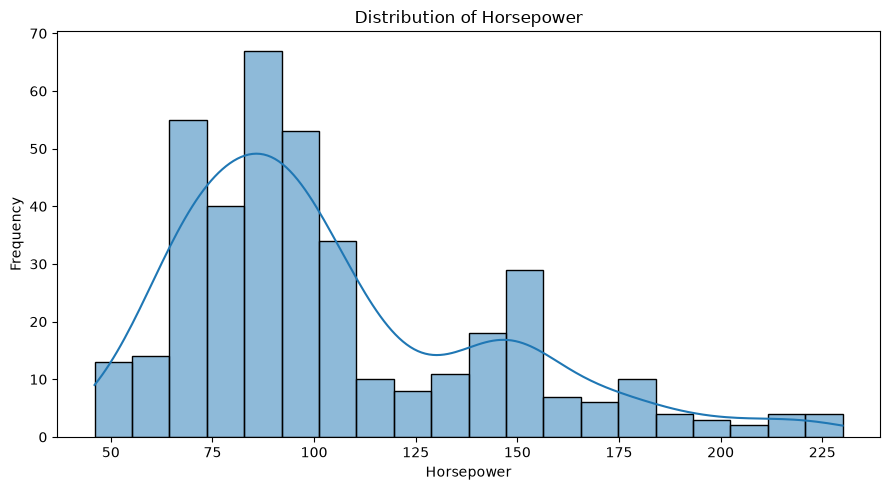

Mean Horsepower: 104.47
Median Horsepower: 93.5
Skewness: 1.09


In [16]:
# TODO: Plot the distribution of a numeric feature such as MPG.
plt.figure(figsize=(9, 5))
sns.histplot(cars_base["Horsepower"].dropna(), bins=20, kde=True)
plt.title("Distribution of Horsepower")
plt.xlabel("Horsepower")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# TODO: Calculate its mean and median.
hp_mean = cars_base["Horsepower"].mean()
hp_median = cars_base["Horsepower"].median()
hp_skew = cars_base["Horsepower"].skew()

print("Mean Horsepower:", round(hp_mean, 2))
print("Median Horsepower:", round(hp_median, 2))
print("Skewness:", round(hp_skew, 2))

- Describe whether it appears symmetric or skewed

The graph is not symmetric, the majority of horsepower are  accumulated at lower values, so the data is skewed to the left.

- Use that evidence to justify whether **mean or median** is a better simple imputation choice.

The median (93.5 hp) sorts all cars from smallest to largest and takes the value remaining in half regardless of the size of values on the right, taking the actual center of the sample. So it is much fairer and more representative when the data are tilted, as in this case




### **Task 3.6 – Apply `SimpleImputer`**

Use Scikit-Learn's `SimpleImputer` on at least one appropriate feature.

Remember the two main stages:

1. `fit` – learn the replacement statistic from the data;
2. `transform` – replace missing values using that statistic.

You may use `fit_transform()` when appropriate, but explain what it combines.

In [17]:
# TODO: Create a SimpleImputer.
# TODO: Fit it to one or more appropriate columns.
# TODO: Transform the data.

cars_imputed = cars_base.copy()
# Create an imputer that learns the median from Horsepower.
imputer = SimpleImputer(strategy="median")

# fit_transform() combines:
# 1) fit: learn the median
# 2) transform: replace missing values with that learned median
cars_imputed[["Horsepower"]] = imputer.fit_transform(
    cars_imputed[["Horsepower"]]
)

# TODO: Verify that the selected missing values were handled.
print("Median learned by SimpleImputer:", imputer.statistics_[0])
print("Missing Horsepower after imputation:", cars_imputed["Horsepower"].isna().sum())

display(cars_imputed.head())

Median learned by SimpleImputer: 93.5
Missing Horsepower after imputation: 0


,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,ModelYear,Origin,CarName
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


### **Task 3.7 – Validate the Cleaned Cars Dataset**

Compare the dataset **before and after cleaning**.

Report:

- shape;
- missing-value counts;
- duplicate counts;
- descriptive statistics for selected numeric columns.

Create at least **one visualization** supporting your comparison.

,Before,After
Shape,"(398, 9)","(398, 9)"
Total Missing Values,6,0
Duplicate Rows,0,0


Selected statistics before cleaning:


,MPG,Horsepower,Weight
count,398.000000,392.000000,398.000000
mean,23.514573,104.469388,2970.424623
std,7.815984,38.491160,846.841774
min,9.000000,46.000000,1613.000000
25%,17.500000,75.000000,2223.750000
50%,23.000000,93.500000,2803.500000
75%,29.000000,126.000000,3608.000000
max,46.600000,230.000000,5140.000000


Selected statistics after cleaning:


,MPG,Horsepower,Weight
count,398.000000,398.000000,398.000000
mean,23.514573,104.304020,2970.424623
std,7.815984,38.222625,846.841774
min,9.000000,46.000000,1613.000000
25%,17.500000,76.000000,2223.750000
50%,23.000000,93.500000,2803.500000
75%,29.000000,125.000000,3608.000000
max,46.600000,230.000000,5140.000000


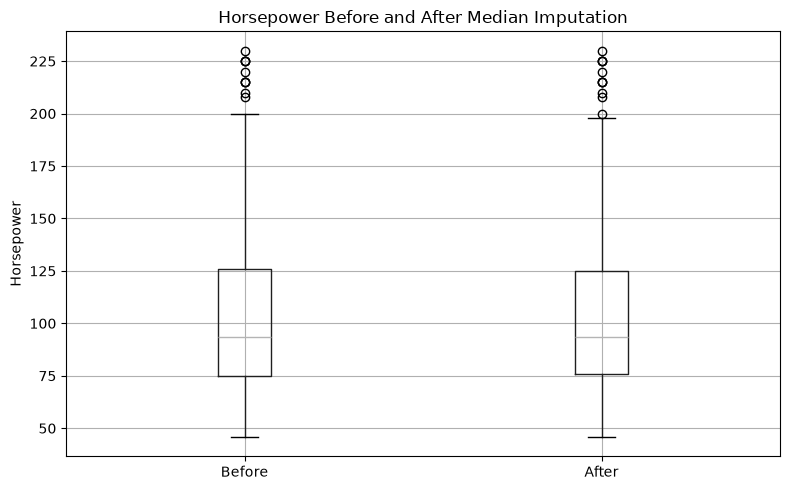

In [18]:
# TODO: Compare before/after statistics and data quality.
cars_clean = cars_imputed.drop_duplicates().copy()

validation_summary = pd.DataFrame({
    "Before": [
        cars_original.shape,
        int(cars_original.isna().sum().sum()),
        int(cars_original.duplicated().sum())
    ],
    "After": [
        cars_clean.shape,
        int(cars_clean.isna().sum().sum()),
        int(cars_clean.duplicated().sum())
    ]
}, index=["Shape", "Total Missing Values", "Duplicate Rows"])

display(validation_summary)

print("Selected statistics before cleaning:")
display(cars_original[["MPG", "Horsepower", "Weight"]].describe())

print("Selected statistics after cleaning:")
display(cars_clean[["MPG", "Horsepower", "Weight"]].describe())

# TODO: Create a supporting visualization.
comparison_hp = pd.DataFrame({
    "Before": cars_original["Horsepower"],
    "After": cars_clean["Horsepower"]
})

plt.figure(figsize=(8, 5))
comparison_hp.boxplot()
plt.title("Horsepower Before and After Median Imputation")
plt.ylabel("Horsepower")
plt.tight_layout()
plt.show()

Initial cleaning:

Shape: It remains the same size (398, 9)  no rows were removed, but empty gaps were filled. 

Total Missing : Went from 6 to 0, 6 missing values were entered in the Horsepower column.

Duplicate Rows: Remains at 0, because none is detected

Chart:

As the 6 data that did not have values were filled with the median (93.5 hp), the dataset was neither modified in its structure nor changed the main statistics. Since there is no exaggerated amount of data but a small amount, the graphics from before and after are not noticeable in any different way and remain almost identical   

### **Task 3.8 – Cars Reflection**

Answer all questions:

1. What were the main data-quality problems?
2. How many missing values did you find?
3. What happened when you dropped rows containing missing values?
4. Why might dropping entire columns be inappropriate?
5. When is mean imputation reasonable?
6. When might median be safer than mean?
7. Where would mode imputation be appropriate?
8. How did `SimpleImputer` differ from manually calling `fillna()`?
9. Did cleaning materially change the dataset statistics?
10. Which cleaning decisions would you carry forward into an ML pipeline, and why?

> **TODO – Cars observations and reflection:**  

1. **What were the main data-quality problems?**  
The most notable problem was that values for the Horsepower column were missing. Furthermore, numerical values, duplicates and possible rows of metadata were reviewed without finding relevant data
2. **How many missing values did you find?**  
For the original file 'Auto-mpg' contains 6 missing values in the field 'Horsepower'
3. **What happened when you dropped rows containing missing values?**  
When missing data was removed, the number of data was reduced from 398 rows to 392
4. **Why might dropping entire columns be inappropriate?**  
Deleting values from a table for as few as they could affect the table’s statistic.
5. **When is mean imputation reasonable?**  
Mean imputation can be applied when one of the numeric values is symmetric and does not contain too large values.
6. **When might median be safer than mean?**  
The median is safer for skewed or extreme data because it is less affected by the extremes of the distribution.
7. **Where would mode imputation be appropriate?**  
Mode imputation is used for variables where averages cannot be calculated. It consists of putting the missing data with the most frequent option, which is valid if there is a larger category in the information
8. **How did `SimpleImputer` differ from manually calling `fillna()`?**  
fillna() calculates the value manually in Pandas, while SimpleImputer learns the statistic with fit() and uses transform() again
9. **Did cleaning materially change the dataset statistics?**  
The statistics only changed slightly as the number of missing values was not too much compared to the total amount and additional median was used to fill in the data
10. **Which cleaning decisions would you carry forward into an ML pipeline, and why?**  
Would maintain numerical conversion for easy operation of operations, duplicate checks and entry of median in cases where required. These techniques can be applied equally at different dates.


# **Section 4 – Outlier Detection (Diabetes Dataset)**

## **Learning Topic: Outlier Detection and Treatment**

An **outlier** is an observation that differs substantially from most of the data. Outliers can result from measurement errors, data-entry problems, unusual but legitimate cases, or genuinely rare events.

Outliers matter because they can affect:

- means and standard deviations;
- correlations;
- regression coefficients;
- distance-based algorithms;
- scaling and normalization;
- model evaluation.

**Important:** Detecting an outlier does **not** automatically mean it should be deleted. You must justify treatment in the context of the data.

## **Getting the Diabetes Dataset from the Internet**

For this section, use the **Pima Indians Diabetes** CSV commonly used in introductory machine-learning exercises. The expected version has **768 observations** and these nine columns:

`Pregnancies`, `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, `BMI`, `DiabetesPedigreeFunction`, `Age`, and `Outcome`.

### Recommended method — download in your browser

A public CSV copy is available here:

`https://raw.githubusercontent.com/npradaschnor/Pima-Indians-Diabetes-Dataset/master/diabetes.csv`

1. Open the address above in a browser.
2. Save the file as **`diabetes.csv`**.
3. Place it in your project's **`data`** folder.
4. Load the local copy:

```python
diabetes = pd.read_csv("./data/diabetes.csv")
```

### Optional Python-assisted download

```python
from pathlib import Path
import pandas as pd

Path("data").mkdir(exist_ok=True)

url = "https://raw.githubusercontent.com/npradaschnor/Pima-Indians-Diabetes-Dataset/master/diabetes.csv"
diabetes = pd.read_csv(url)
diabetes.to_csv("./data/diabetes.csv", index=False)
```

### Verify before continuing

Run:

```python
diabetes.shape
diabetes.head()
diabetes.columns
```

For the expected file, the shape should be `(768, 9)` and the columns should match the list above.

### Important data-quality warning

In this dataset, some physiological variables contain **zero values** that may represent unavailable or invalid measurements rather than plausible measurements. Do not automatically treat every zero as an outlier or delete it. Inspect the variable meaning first, document your decision, and keep the focus of this section on comparing the required outlier-detection methods.

> **Dataset-name warning:** UCI also hosts a dataset simply called **Diabetes**, but it is a different time-series dataset. For this particular lab, use the nine-column Pima-style CSV described above so your work matches the assignment.

### **Task 4.1 – Load and Explore the Diabetes Dataset**

1. Load the Diabetes dataset from your data folder.
2. Display shape, columns, data types, and descriptive statistics.
3. Identify the numeric features you will examine for outliers.
4. Check for missing or obviously invalid values before outlier analysis.

In [19]:
# TODO: Load the Diabetes dataset.
diabetes = pd.read_csv("../data/diabetes.csv")
diabetes_original = diabetes.copy()

# TODO: Inspect shape, columns, dtypes, head(), and describe().
print("Shape:", diabetes.shape)
print("\nColumns:", diabetes.columns.tolist())
print("\nData types:")
print(diabetes.dtypes)
print("\nFirst rows:")
display(diabetes.head())

# TODO: Identify numeric features for outlier analysis.
# All predictor columns are numeric; Outcome is the target.
numeric_features = [
    col for col in diabetes.columns if col != "Outcome"
]
print("Numeric features for outlier analysis:", numeric_features)

print("\nMissing values:")
print(diabetes.isna().sum())

# Some zeros are not physiologically realistic and may represent unavailable measurements.
zero_check_columns = [
    "Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"
]
zero_counts = (diabetes[zero_check_columns] == 0).sum()
print("\nPotentially invalid zero values:")
print(zero_counts)

Shape: (768, 9)

Columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Data types:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

First rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Numeric features for outlier analysis: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

Missing values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Potentially invalid zero values:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


### **Task 4.2 – Box Plot Method**

Create box plots for selected numeric features.

Use the plots to:

- identify observations outside the whiskers;
- compare which variables appear to contain more extreme values;
- explain what the box, median, quartiles, and whiskers represent.

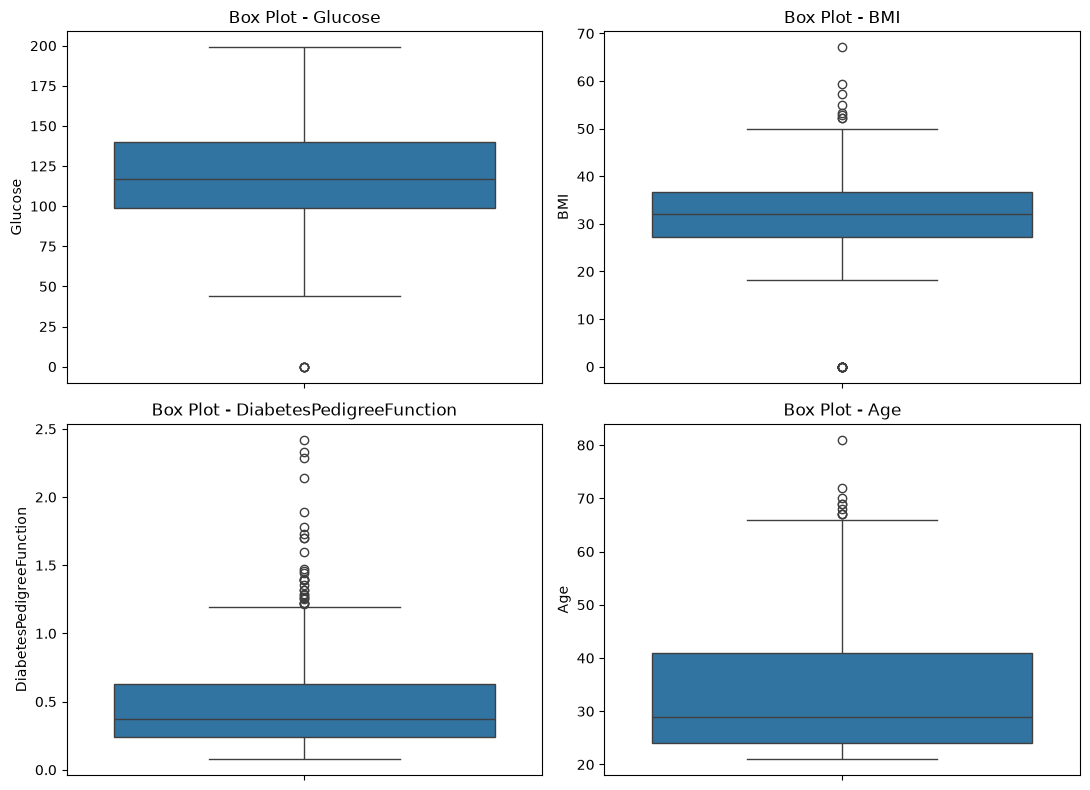

In [20]:
# TODO: Create one or more box plots.
# TODO: Label plots clearly.

box_features = ["Glucose", "BMI", "DiabetesPedigreeFunction", "Age"]

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes = axes.flatten()

for ax, feature in zip(axes, box_features):
    sns.boxplot(y=diabetes[feature], ax=ax)
    ax.set_title(f"Box Plot - {feature}")
    ax.set_ylabel(feature)
    ax.set_xlabel("")

plt.tight_layout()
plt.show()

Dots outside the box do not mean that we should erase that data. Some are errors while others are real but extreme cases that must be reviewed before deciding whether to clean or keep.
Understanding each graphic

Glucose 

Most data or people are in a typical range of between 100 and 140. In the end, a figure is observed at 0. According to an internet search, glucose at zero is impossible for a living person, which may mean that it is a registration error. 
BMI 
The graphics indicate that the average is between 27 and 37 of BMI. Like the previous one, there is a figure in 0 that may again mean error; however, we also observe more data above the box’s measurement, which may mean people with possible overweight.

DiabetesPedigreeFunction

The graphics tell us that people have a low score, less than about 0.6. In this graphic we can also observe points outside the average, these cannot be treated as an error, they could mean that the hereditary burden of diabetes is higher than the rest. 

Age

The people surveyed are on average around 24 and 41 years old. The points outside the average represent older people who were also surveyed, if there were points at or below zero these would be considered an error 


### **Task 4.3 – Scatter Plot Method**

Create at least one scatter plot using two meaningful numeric features.

Use the plot to identify observations that appear isolated from the main cluster of data.

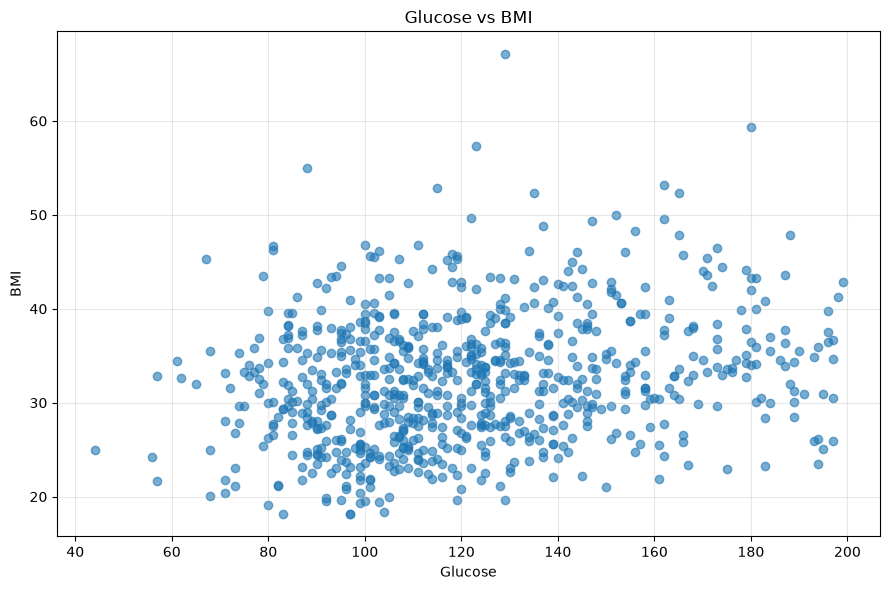

In [21]:
# TODO: Create a scatter plot for two meaningful numeric features.
scatter_data = diabetes[
    (diabetes["Glucose"] > 0) & (diabetes["BMI"] > 0)
].copy()

# TODO: Identify visually unusual observations.
plt.figure(figsize=(9, 6))
plt.scatter(scatter_data["Glucose"], scatter_data["BMI"], alpha=0.6)
plt.title("Glucose vs BMI")
plt.xlabel("Glucose")
plt.ylabel("BMI")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The graphic above is a dispersion diagram between Glucose and BMI that shows most patients are concentrated in a central cloud with glucose levels between 80-160 and BMI between 20-45. Although we can see extreme values in both variables, these data may represent severe but physically possible clinical cases.  

### **Task 4.4 – Z-Score Method**

For a numeric feature, calculate:

\[
z = \frac{x - \mu}{\sigma}
\]

Use the conventional threshold:

\[
|z| > 3
\]

to flag potential outliers.

Report the number of observations identified.

In [22]:
# TODO: Calculate Z-Scores for a selected numeric feature (or features).
outlier_feature = "DiabetesPedigreeFunction"

feature_mean = diabetes[outlier_feature].mean()
feature_std = diabetes[outlier_feature].std(ddof=0)

z_scores = (diabetes[outlier_feature] - feature_mean) / feature_std
z_mask = z_scores.abs() > 3
z_outliers = diabetes.loc[z_mask].copy()
z_outlier_count = int(z_mask.sum())

print("Feature:", outlier_feature)
print("Mean:", round(feature_mean, 4))
print("Standard deviation:", round(feature_std, 4))

# TODO: Identify rows where abs(z) > 3.
print("Z-Score outliers (|z| > 3):", z_outlier_count)

# TODO: Report the outlier count.
display(z_outliers[[outlier_feature, "Outcome"]].head(10))

Feature: DiabetesPedigreeFunction
Mean: 0.4719
Standard deviation: 0.3311
Z-Score outliers (|z| > 3): 11


,DiabetesPedigreeFunction,Outcome
4,2.288,1
45,1.893,1
58,1.781,0
228,2.329,0
330,1.476,0
370,2.137,1
371,1.731,0
395,1.600,0
445,2.420,1
593,1.699,0


### **Task 4.5 – Interquartile Range (IQR) Method**

Calculate:

\[
IQR = Q3 - Q1
\]

Then calculate:

\[
Lower\ Bound = Q1 - 1.5(IQR)
\]

\[
Upper\ Bound = Q3 + 1.5(IQR)
\]

Identify observations outside those bounds and report the outlier count.

In [23]:
# TODO: Calculate Q1, Q3, and IQR.
Q1 = diabetes[outlier_feature].quantile(0.25)
Q3 = diabetes[outlier_feature].quantile(0.75)
IQR = Q3 - Q1

# TODO: Calculate lower and upper bounds.
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# TODO: Identify and count IQR outliers.
iqr_mask = (
    (diabetes[outlier_feature] < lower_bound)
    | (diabetes[outlier_feature] > upper_bound)
)

iqr_outliers = diabetes.loc[iqr_mask].copy()
iqr_outlier_count = int(iqr_mask.sum())

print("Q1:", round(Q1, 4))
print("Q3:", round(Q3, 4))
print("IQR:", round(IQR, 4))
print("Lower bound:", round(lower_bound, 4))
print("Upper bound:", round(upper_bound, 4))
print("IQR outliers:", iqr_outlier_count)

display(iqr_outliers[[outlier_feature, "Outcome"]].head(10))

Q1: 0.2438
Q3: 0.6262
IQR: 0.3825
Lower bound: -0.33
Upper bound: 1.2
IQR outliers: 29


,DiabetesPedigreeFunction,Outcome
4,2.288,1
12,1.441,0
39,1.390,1
45,1.893,1
58,1.781,0
100,1.222,1
147,1.400,0
187,1.321,1
218,1.224,1
228,2.329,0


### **Task 4.6 – Compare Detection Methods**

Create a small comparison showing the number of potential outliers identified by:

- Box Plot / IQR interpretation
- Z-Score
- IQR rule

Explain why the methods may identify different observations.

In [24]:
# TODO: Summarize outlier counts from the different methods.
outlier_comparison = pd.DataFrame({
    "Method": ["Box Plot / IQR interpretation", "Z-Score", "IQR rule"],
    "Potential Outliers": [
        iqr_outlier_count,
        z_outlier_count,
        iqr_outlier_count
    ]
})

display(outlier_comparison)

,Method,Potential Outliers
0,Box Plot / IQR interpretation,29
1,Z-Score,11
2,IQR rule,29


Methods can have different results because they handle different methodologies to an outlier. 
- Z-Score uses the mean and standard deviation is commonly used when distribution is normal. 
- The IQR uses quartiles, so it is less affected by skewed data and extreme values.
- A box chart visually represents the same idea of 1.5 IQR used by the IQR rule.

### **Task 4.7 – Treat Outliers Carefully**

Create a cleaned copy of the dataset and remove outliers **only where you can justify doing so**.

Do not overwrite the original dataframe.

Compare before and after:

- number of rows;
- mean;
- median;
- standard deviation;
- relevant visualizations.

,Before,After
count,768.000000,739.000000
mean,0.471876,0.429832
median,0.372500,0.356000
std,0.331329,0.249684


Rows before: 768
Rows after: 739
Rows removed: 29


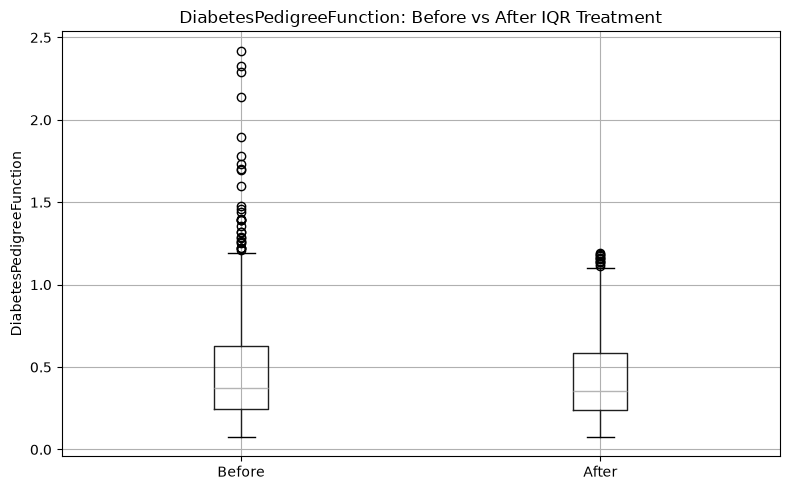

In [25]:
# TODO: Create a cleaned COPY of the data.
# TODO: Remove justified outliers using a clearly documented rule.
diabetes_clean = diabetes.loc[~iqr_mask].copy()

before_stats = diabetes[outlier_feature].agg(["count", "mean", "median", "std"])
after_stats = diabetes_clean[outlier_feature].agg(["count", "mean", "median", "std"])

stats_comparison = pd.DataFrame({
    "Before": before_stats,
    "After": after_stats
})

display(stats_comparison)

# TODO: Compare before/after statistics.
print("Rows before:", len(diabetes))
print("Rows after:", len(diabetes_clean))
print("Rows removed:", len(diabetes) - len(diabetes_clean))

# TODO: Recreate at least one visualization after treatment.
plot_compare = pd.DataFrame({
    "Before": diabetes[outlier_feature],
    "After": diabetes_clean[outlier_feature]
})

plt.figure(figsize=(8, 5))
plot_compare.boxplot()
plt.title(f"{outlier_feature}: Before vs After IQR Treatment")
plt.ylabel(outlier_feature)
plt.tight_layout()
plt.show()

### **Task 4.8 – Diabetes Reflection**

Answer all questions:

1. What is an outlier?
2. What are at least three possible causes of outliers?
3. Which variables showed the clearest visual outliers?
4. How many observations were flagged by the Z-Score method?
5. How many were flagged by the IQR method?
6. Why can Z-Score and IQR produce different results?
7. When should an outlier be retained?
8. When might removing an outlier be justified?
9. How did removal affect the descriptive statistics?
10. How could untreated outliers affect a downstream ML model?

> **TODO – Diabetes observations and reflection:**  

1. **What is an outlier?**  
It is a value that in its characteristics is not within the normal values, is very far from the average
2. **What are at least three possible causes of outliers?**  
There are several causes in which measurement errors, data entry errors and actual but rare observations may occur.
3. **Which variables showed the clearest visual outliers?**  
DiabetesPedigreeFunction returned strange values. `BMI`, `Age` and among other measurements also showed unusual values as observed in the graphs.
4. **How many observations were flagged by the Z-Score method?**  
The exact `DiabetesPedigreeFunction` count was printed in Part 4.4 as `z_outlier_count` with a result of 11
5. **How many were flagged by the IQR method?**  
The result was printed in part 4.5 as `iqr_outlier_count` with a result of 29
6. **Why can Z-Score and IQR produce different results?**  
The Z-Score depends on average and standard deviation, while the IQR depends on quartiles. The IQR is often used when data are biased.
7. **When should an outlier be retained?**  
The deletion of isolated data depends entirely on the problem or context that is being used, as we saw in these cases, some can be real measures and sometimes a 0 does not mean it is an erroneous or missing data
8. **When might removing an outlier be justified?**  
Removing may be justified when sufficient understanding and evidence that the value is an error must be documented for certainty in a similar future case
9. **How did removal affect the descriptive statistics?**  
The removal of values reduces the mean and standard deviation more than the median because the mean and standard deviation are more sensitive to extreme values.
10. **How could untreated outliers affect a downstream ML model?**  
May change model averages, scale, distances, correlations, and coefficients, which may make some models less stable


# **Final Validation and Submission Checklist**

Before submitting:

- [ ] All four required sections are in this single notebook.
- [ ] PEW uses `pd.melt()` or `DataFrame.melt()`.
- [ ] Billboard uses `melt()` and Pandas string manipulation.
- [ ] Cars demonstrates missing-value analysis, dropping, imputation, duplicates, and validation.
- [ ] Diabetes includes box plot, scatter plot, Z-Score, and IQR.
- [ ] Every required visualization has a meaningful title and axis labels.
- [ ] Reflection questions are answered in Markdown.
- [ ] Data is loaded using relative paths from a clearly named data folder.
- [ ] `README.md`, `requirements.txt`, and `.gitignore` are included.
- [ ] There are no unnecessary `!pip install` cells.
- [ ] You restarted the kernel and successfully ran **Run All** from top to bottom.

# **General Guidelines**

## Expected Observations

### PEW
- Income categories are encoded as column headings in the original wide dataset.
- `melt()` should preserve religion as an identifier while moving income categories into rows.
- The long form is easier to group, filter, and visualize.

### Billboard
- Weekly rankings are stored across repeated week columns.
- `melt()` converts weekly columns into observations.
- Week labels usually require string cleanup/extraction before numeric analysis.
- Missing rankings often indicate that a song was not ranked in that week and should not automatically be imputed.

### Cars
- Students should inspect before deleting the first row; removal should be evidence-based.
- Some numeric-looking columns may require conversion from `object`.
- Mean imputation is sensitive to skew/outliers; median can be more robust.
- Dropping every column containing a missing value is generally too destructive when missingness is small.

### Diabetes
- Box plots and IQR are closely related but students should understand that visualization and rule-based detection serve different purposes.
- Z-Score works best when a roughly normal-distribution assumption is reasonable.
- IQR is more robust for skewed distributions.
- Outliers should not be removed automatically without context.

## Common Mistakes

- Using absolute paths such as `C:\Users\...`.
- Treating `melt()` as equivalent to simply renaming columns.
- Cleaning Billboard week labels without converting the result to numeric.
- Filling every missing value with zero.
- Dropping data without first reporting the effect.
- Using `|z| > 2` when the assignment specifies `|z| > 3`.
- Computing IQR incorrectly or reversing the lower/upper bound formulas.
- Removing outliers from the original dataframe and losing the baseline for comparison.
- Producing plots without titles, labels, or interpretation.
- Adding `!pip install` cells even though the project includes `requirements.txt`.

## Suggested Instructor Solutions / Checks

- Accept both `pd.melt(df, ...)` and `df.melt(...)`.
- Accept logically equivalent Pandas string-cleaning approaches.
- For missing values, grade the quality of the justification, not only the specific method selected.
- Require evidence that the notebook runs sequentially.
- Confirm that each data file is loaded from the submitted project using relative paths.

## Stretch Challenges

1. Build reusable functions for tidying and cleaning.
2. Compare multiple imputation strategies quantitatively.
3. Use `ColumnTransformer` or a Scikit-Learn preprocessing pipeline.
4. Compare outlier treatment before/after scaling.
5. Investigate how removing outliers changes a simple regression model.
6. Export cleaned datasets to a `processed/` subfolder without overwriting raw data.